# Bài tập thực hành tuần 9
> Họ và tên: Nguyễn Vạn Phúc Huy <br>
> MSSV: 23110163 <br>
> Lớp: 23TTH (Chiều thứ 6, ca 1)

### Áp dụng với tập dữ liệu banknote authentication từ UCI Machine Learning Repository. Kiểm tra banknote là tuyến tính hay không tuyến tính rồi áp dụng tương tự trường hợp tương ứng như trên.

Lấy dữ liệu và chia cột

In [13]:
link_hd_ko_che= r'https://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt'
columns = ['variance', 'skewness', 'curtosis', 'entropy', 'class']
df = pd.read_csv(link_hd_ko_che, names=columns)
df

,variance,skewness,curtosis,entropy,class
0,3.62160,8.66610,-2.8073,-0.44699,0
1,4.54590,8.16740,-2.4586,-1.46210,0
2,3.86600,-2.63830,1.9242,0.10645,0
3,3.45660,9.52280,-4.0112,-3.59440,0
4,0.32924,-4.45520,4.5718,-0.98880,0
...,...,...,...,...,...
1367,0.40614,1.34920,-1.4501,-0.55949,1
1368,-1.38870,-4.87730,6.4774,0.34179,1
1369,-3.75030,-13.45860,17.5932,-2.77710,1
1370,-3.56370,-8.38270,12.3930,-1.28230,1


Pre-processing data

In [14]:
from sklearn.preprocessing import StandardScaler
X = df.drop('class', axis=1)
y = df['class']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Splitting data

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=69)

In [16]:
# Mô hình Tuyến tính (Linear Margin)
svm_linear = SVC(kernel='linear', C=1.0)
svm_linear.fit(X_train, y_train)
acc_linear = accuracy_score(y_test, svm_linear.predict(X_test))

# Mô hình Phi tuyến tính (Soft Margin - RBF Kernel)
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='auto')
svm_rbf.fit(X_train, y_train)
acc_rbf = accuracy_score(y_test, svm_rbf.predict(X_test))

print(f"Độ chính xác của SVM Tuyến tính (Linear): {acc_linear * 100:.2f}%")
print(f"Độ chính xác của SVM Phi tuyến tính (RBF): {acc_rbf * 100:.2f}%")

Độ chính xác của SVM Tuyến tính (Linear): 98.79%
Độ chính xác của SVM Phi tuyến tính (RBF): 100.00%


Dựa vào kết quả ở trên, ta thấy mô hình SVM sử dụng Kernel Linear cho độ chính xác rất cao (98.79%), cho thấy dữ liệu có tính phân tách tuyến tính khá tốt. Khi sử dụng Kernel RBF thì độ chính xác đạt mức tuyệt đối (100%). Điều này chứng tỏ ranh giới giữa hai lớp (tiền thật - tiền giả) vẫn có sự lồng ghép phức tạp và mang tính phi tuyến. Do đó, việc áp dụng mô hình SVM phi tuyến là lựa chọn tốt nhất cho tập dữ liệu này.

In [17]:
X_2d = X_scaled[:, :2]

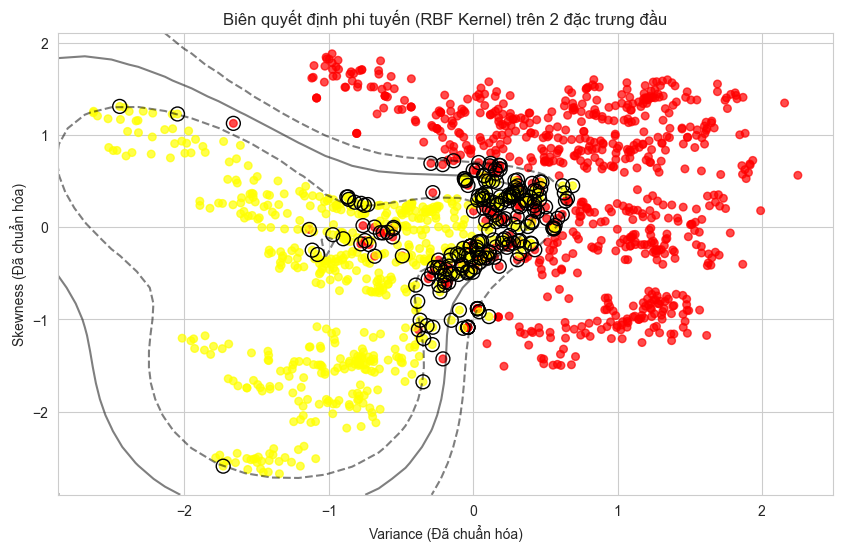

array([[ 0.62764917, -0.68825631],
       [ 1.00554504, -0.26828226],
       [-0.66498755,  0.63680074],
       [ 0.87322223,  0.30293878],
       [-0.8462068 , -0.29518508],
       [ 0.18066449,  0.98254254],
       [ 0.52212463,  0.75074293],
       [-0.16241969, -0.85643361],
       [-0.77978477,  0.39040117],
       [-0.27877436,  0.13360838],
       [-0.13006067, -0.25884467],
       [ 0.36186446,  0.06808468]])

In [19]:
# Hàm vẽ biên quyết định (tương tự như trong bài thực hành)
def plot_svc_decision_function(model, ax=None, plot_support=True):
    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    # Tạo lưới để đánh giá mô hình
    x = np.linspace(xlim[0], xlim[1], 30)
    y_grid = np.linspace(ylim[0], ylim[1], 30)
    Y, X_grid = np.meshgrid(y_grid, x)
    xy = np.vstack([X_grid.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X_grid.shape)
    
    # Vẽ biên quyết định và lề
    ax.contour(X_grid, Y, P, colors='k',
               levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])
    
    # Vẽ support vectors
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   s=100, linewidth=1, edgecolors='black',
                   facecolors='none')
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

# Huấn luyện lại mô hình RBF trên dữ liệu 2D để trực quan hóa
svm_rbf_2d = SVC(kernel='rbf', C=10)
svm_rbf_2d.fit(X_2d, y)

# Vẽ đồ thị
plt.figure(figsize=(10, 6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, s=30, cmap='autumn', alpha=0.7)
plot_svc_decision_function(svm_rbf_2d)
plt.title("Biên quyết định phi tuyến (RBF Kernel) trên 2 đặc trưng đầu")
plt.xlabel("Variance (Đã chuẩn hóa)")
plt.ylabel("Skewness (Đã chuẩn hóa)")
plt.show()
model.support_vectors_